# THE DEUTSCH-JOZSA ALGORITHM

We are going to use Qiskit to implement the Deutsch-Jozsa algorithm 

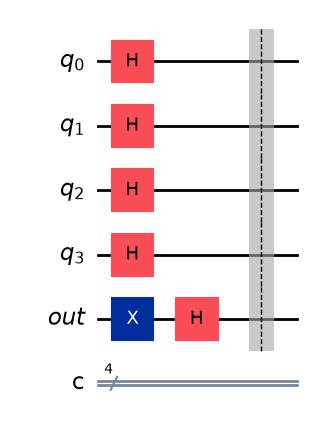

In [1]:
%matplotlib inline

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

n = 4 # Number of qubits that we are going to use in the oracle

q   = QuantumRegister(n, 'q') # The oracle qubits
out = QuantumRegister(1, 'out') # Qubit for the oracle output
c   = ClassicalRegister(n, 'c') # Classical bits needed for the result of the measurement

circ_init = QuantumCircuit(q,out,c) # Initial part of the circuit

# We apply H to all the oracle qubits
for i in range(n):    
    circ_init.h(q[i]) 

# We apply X and H to the output qubit    
circ_init.x(out)  
circ_init.h(out)

circ_init.barrier()

circ_init.draw(output='mpl');

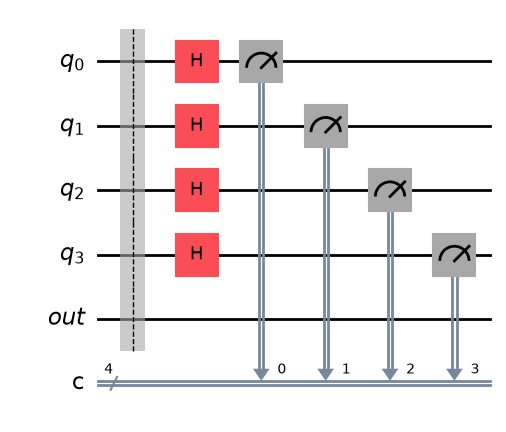

In [2]:
circ_end = QuantumCircuit(q,out,c)

circ_end.barrier() # Visual barrier to separate the parts of the circuit

for i in range(n):    
    circ_end.h(q[i]) # We apply H to all the oracle qubits
    
circ_end.measure(q,c)

circ_end.draw(output='mpl');

Now, we are going to define two oracles to check the behaviour of the algorithm. One will be a circuit for a constant function and the other, for a balanced function.

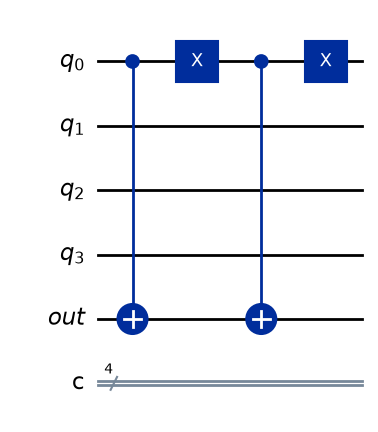

In [3]:
# Oracle for a boolean function that always returns 1 
    
const = QuantumCircuit(q,out,c)
const.cx(q[0],out)
const.x(q[0])
const.cx(q[0],out)
const.x(q[0])

const.draw(output='mpl');

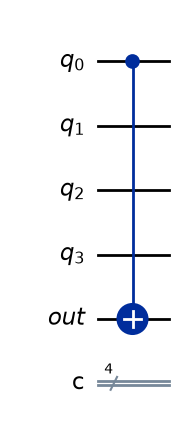

In [4]:
# Oracle for a boolean function that returns 1 for half of the inputs
    
bal = QuantumCircuit(q,out,c)
bal.cx(q[0],out)

bal.draw(output='mpl');

We create the circuit with the oracle for the constant function

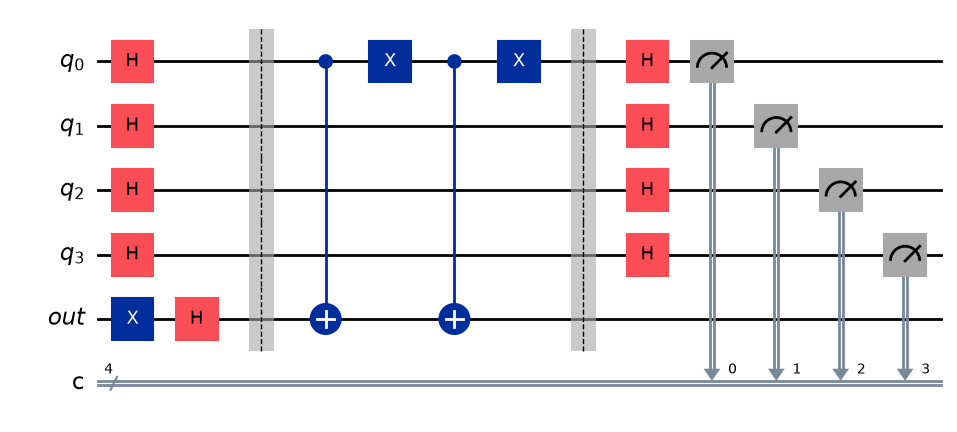

In [5]:
circ_const = circ_init.compose(const).compose(circ_end) # combining the QuantumCircuits
circ_const.draw(output='mpl');

When we execute it, the result of the measure is, as expected, a string formed only by zeroes.

In [6]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

job = sampler.run([circ_const], shots=10)
counts = job.result()[0].data.c.get_counts()
print(counts)

{'0000': 10}


Finally, we build the circuit for the balanced function.

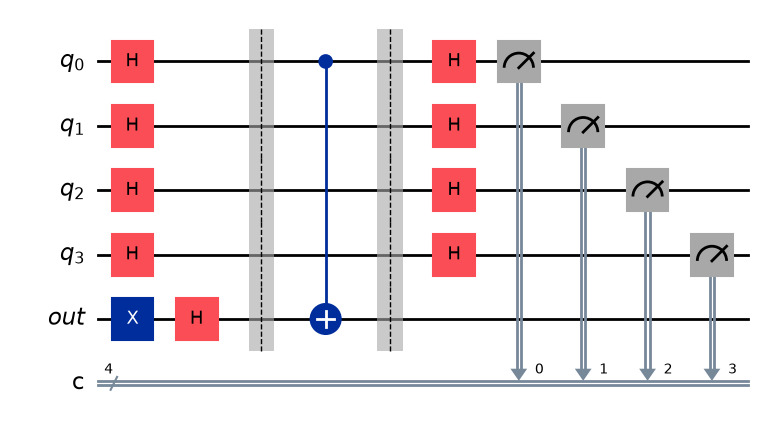

In [7]:
circ_bal = circ_init.compose(bal).compose(circ_end)
circ_bal.draw(output='mpl');

When we run it, we always obtain a string that is not all zeroes.

In [8]:
job = sampler.run([circ_bal], shots=10)
counts = job.result()[0].data.c.get_counts()
print(counts)

{'0001': 10}


We are now going to execute the circuit on a quantum computer

In [ ]:
RUN_IBM_HARDWARE = False
# Optional IBM Quantum hardware section. Set RUN_IBM_HARDWARE to True only after configuring a local provider account.
if RUN_IBM_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    from qiskit.transpiler import generate_preset_pass_manager


    # Optional IBM Quantum hardware section. Configure a local IBM Quantum account before running this section.
    # No credential is stored in this notebook or repository.

    service = QiskitRuntimeService()

    backend = service.least_busy(simulator=False, operational=True, min_num_qubits=4)

    print("We are executing on:", backend)
    print("We are using...", backend)
    print("It has", backend.status().pending_jobs, "pending jobs")

    # Send both circuits at once
    circuits = [circ_const, circ_bal]

    # Transpile circuits for the selected IBM hardware
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1
    )
    circuits_transpiled = [pm.run(circuit) for circuit in circuits]

    sampler = Sampler(mode=backend)
    job_exp = sampler.run(circuits_transpiled)

    print("Job ID:", job_exp.job_id())
    print("Final status:", job_exp.status())

    # Wait for the job to finish
    result_exp = job_exp.result()
else:
    print("Skipping optional IBM Quantum hardware section.")


Once the job is done, we obtain and show the results

In [12]:
result_exp = job_exp.result()
counts_const = result_exp[0].data.c.get_counts()
print("Results for the circuit with the constant function")
print(counts_const)

print("\n" + "=" * 100 + "\n")

counts_bal = result_exp[1].data.c.get_counts()
print("Results for the circuit with the balanced function")
print(counts_bal)

Results for the circuit with the constant function
{'0100': 65, '0000': 3923, '1000': 43, '0010': 11, '0001': 53, '1100': 1}


Results for the circuit with the balanced function
{'0001': 3938, '0011': 10, '1001': 26, '0101': 39, '0000': 82, '1000': 1}
